# Future projections of global hail hazard - code demo

This demo shows the calculation of convective parameters and hail proxies from CMIP6 data.

In [1]:
%cd ~/git/future_hail_global

/home/561/tr2908/git/future_hail_global


In [2]:
import sys
from pathlib import Path

sys.path.append(f'{Path("~").expanduser()!s}/git/xarray_parcel/')
sys.path.append(f'{Path("~").expanduser()!s}/git/warming_levels/')

import sys

import modules.fut_hail as fh
import modules.updated_proxy as up
import xarray

Read the demo data from CMIP6. These data is sourced from the GISS-E2-1-G NASA-GISS model for the historical period, and subset to one timestep as an example. This model's data is licensed under a Creative Commons Attribution ShareAlike 4.0 International License (https://creativecommons.org/licenses). CMIP6 data is available at https://doi.org/10.25914/Q1CT-RM13. 

In [3]:
d = xarray.open_dataset('demo/CMIP6.CMIP.NASA-GISS.GISS-E2-1-G.historical.r1i1p1f2.19900101000000.nc').isel(time=0)

Convert from longitude 0-360 to -180 to 180.

In [4]:
d['lon'] = d.lon.where(d.lon < 180, other=d.lon - 360)
d = d.sortby('lon')
d = d.drop_vars('height')

Calculate convective parameters used by hail proxies.

In [5]:
d['height_asl'], d['wind_height_above_surface'] = fh.geopotential_height(d)
c = fh.conv_properties(dat=d, vert_dim='lev').load()

Calculating dewpoint...
Calculating mixed-parcel CAPE and CIN (100 hPa)...
Calculating lifted indices...
700-500 hPa lapse rate...
Temperature at 500 hPa...
Freezing level height...
Melting level height...
Calculating wet bulb temperature...
0-6 km vertical wind shear...
Calculating most-unstable CAPE and CIN...
Calculating deep convective indices...
Calculating mixing ratio of most unstable parcel...
Merging results...


As a demo, plot temperature at 500 hPa and CAPE:

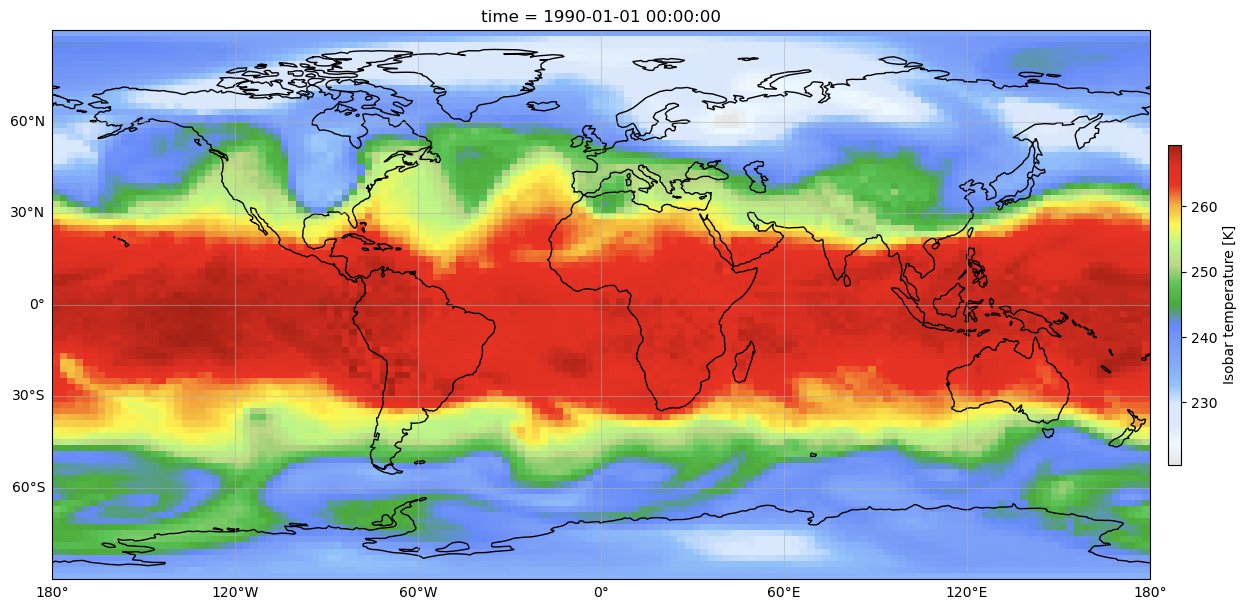

In [6]:
_ = fh.plot_map(c.temp_500)

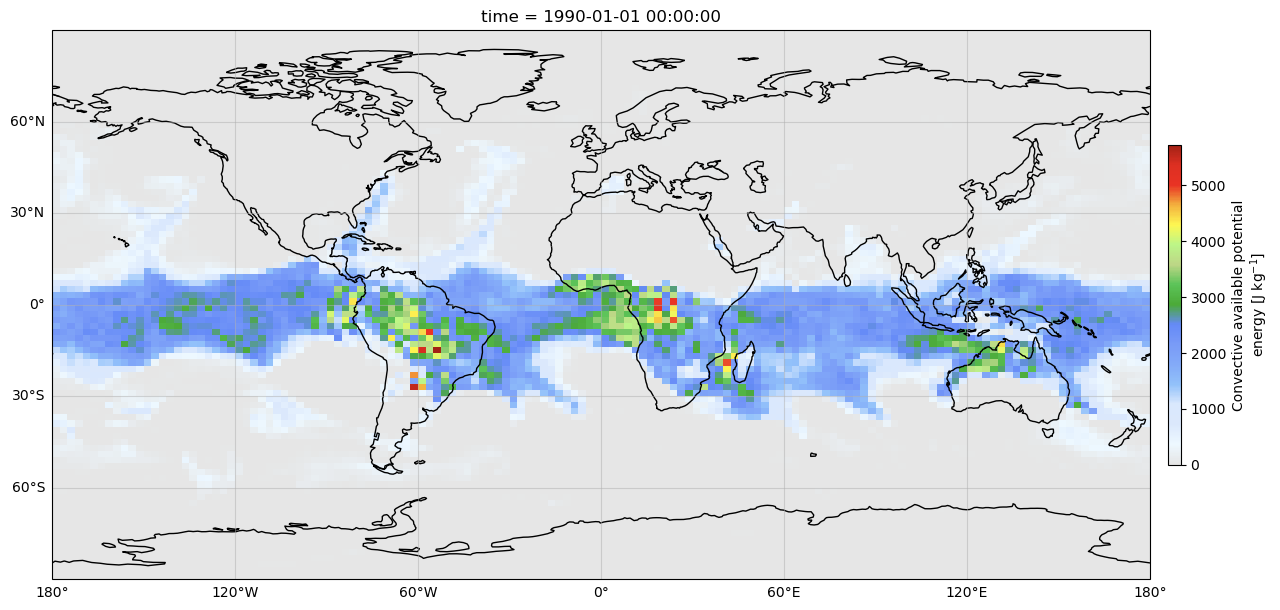

In [7]:
_ = fh.plot_map(c.mixed_100_cape)

Calculate hail proxies.

In [8]:
# Calculate literature cape-shear proxies.
print('Literature proxies...')
prox = fh.storm_proxies(dat=c)

# Add Raupach hail proxies.
print('Raupach proxies...')
prox['proxy_Raupach2023'] = up.apply_Raupach_proxy(
    dat=c,
    results_file='demo/results_era5.json',
    extra_conds_file='demo/era5_proxy_extra_conds.csv',
    band_limits=[2000, None],
    load=False,
)

Literature proxies...
Raupach proxies...


Plot proxy results for this timestep.

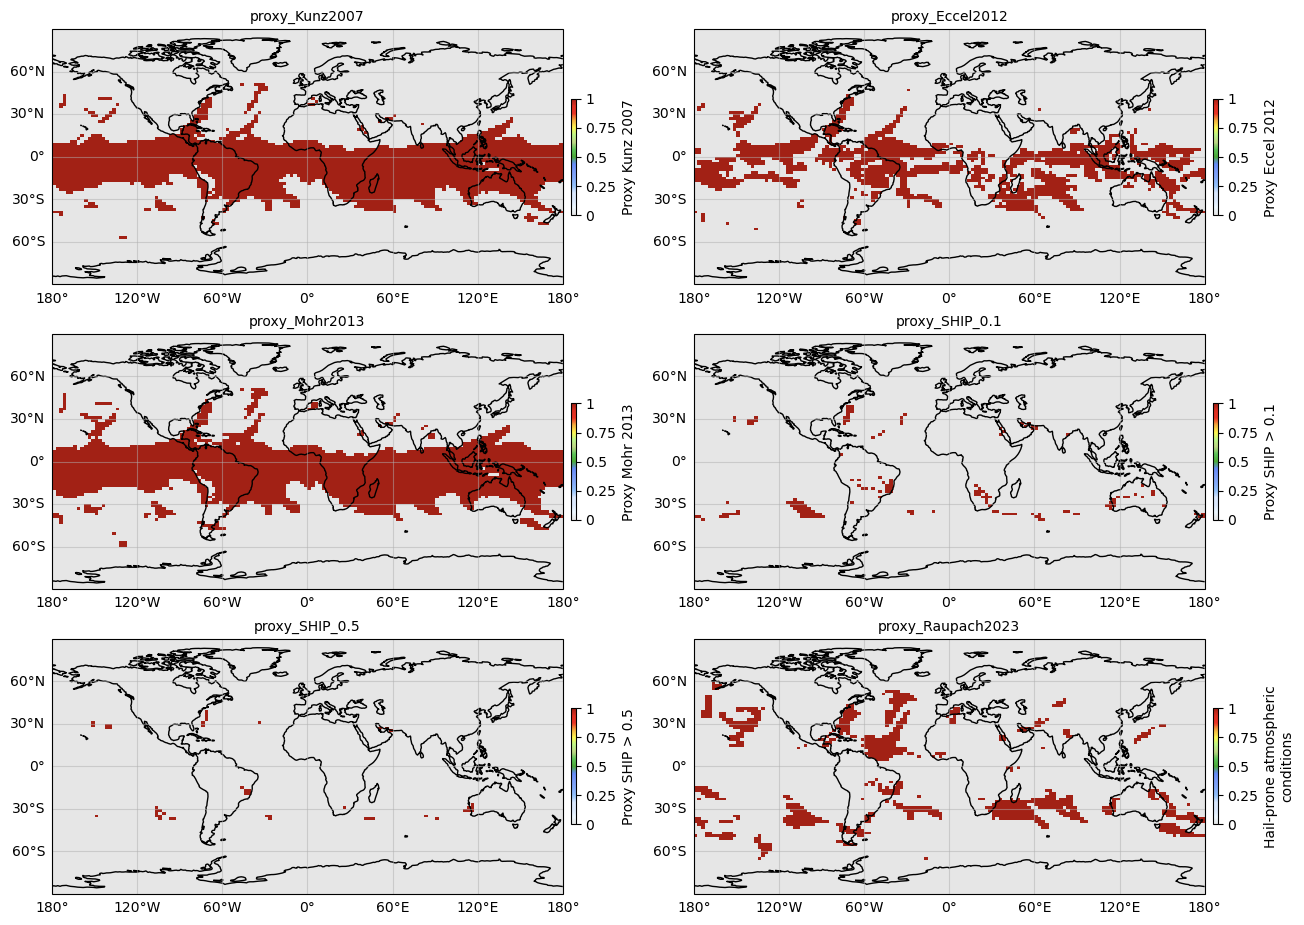

In [9]:
proxies = ['proxy_Kunz2007', 'proxy_Eccel2012', 'proxy_Mohr2013', 'proxy_SHIP_0.1', 'proxy_SHIP_0.5', 'proxy_Raupach2023']
_ = fh.plot_map([prox[v] for v in proxies], ncols=2, nrows=3, title=proxies, figsize=(12,9), wspace=0.15)